# KMeans 第二课：距离与目标函数

第一课已经建立了 K-means 的整体直觉：

```text
初始化质心
-> 把样本分配给最近的质心
-> 用簇内均值更新质心
-> 重复直到稳定
```

这一课把其中两个词彻底说清楚：

```text
“最近”怎样计算？
“当前分组好不好”怎样衡量？
```

答案分别是：

- 用距离决定样本属于哪个质心；
- 用簇内平方和衡量整个聚类结果。

In [1]:
import os

# 避免 Windows + MKL 环境在小型 K-means 数据上产生已知警告
os.environ["OMP_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

np.set_printoptions(precision=3, suppress=True)

## 1. 欧氏距离：两点之间有多远？

在二维平面中，样本 $x=(x_1,x_2)$ 和质心 $\mu=(\mu_1,\mu_2)$ 的欧氏距离是：

$$
d(x,\mu)
=
\sqrt{(x_1-\mu_1)^2+(x_2-\mu_2)^2}
$$

推广到 $n$ 个特征：

$$
d(x,\mu)
=
\lVert x-\mu\rVert_2
=
\sqrt{\sum_{j=1}^{n}(x_j-\mu_j)^2}
$$

这和 KNN 使用的欧氏距离完全相同。区别只在比较对象：

```text
KNN     -> 新样本与训练样本之间的距离
K-means -> 每个样本与各个质心之间的距离
```

In [2]:
# 一个样本到两个候选质心的距离
x = np.array([2.0, 3.0])
centers_demo = np.array([
    [1.0, 1.0],
    [6.0, 7.0],
])

differences = x - centers_demo
squared_distances_demo = np.sum(differences ** 2, axis=1)
distances_demo = np.sqrt(squared_distances_demo)

print("差向量:")
print(differences)
print("平方距离:", squared_distances_demo)
print("欧氏距离:", distances_demo)
print("最近质心编号:", np.argmin(distances_demo))

差向量:
[[ 1.  2.]
 [-4. -4.]]
平方距离: [ 5. 32.]
欧氏距离: [2.236 5.657]
最近质心编号: 0


## 2. 为什么经常直接使用平方距离？

如果两个距离满足：

$$
d_1<d_2
$$

因为距离都是非负数，所以平方以后仍有：

$$
d_1^2<d_2^2
$$

因此，要判断哪个质心更近，并不一定要计算平方根。

例如：

```text
平方距离 5  < 平方距离 32
欧氏距离 √5 < 欧氏距离 √32
```

两种方法选出的最近质心相同。K-means 的目标函数也直接累加平方距离，所以代码中经常保留平方距离。

## 3. 准备一组可以手算的数据

使用 6 个二维样本：

```text
左下角三点：(1,1)、(1,2)、(2,1)
右上角三点：(8,8)、(8,9)、(9,8)
```

先指定两个初始质心：

$$
\mu_0=(1,1),\qquad \mu_1=(8,8)
$$

因为这组数据结构很清楚，我们容易检查每一步计算是否正确。

In [3]:
X = np.array([
    [1.0, 1.0],
    [1.0, 2.0],
    [2.0, 1.0],
    [8.0, 8.0],
    [8.0, 9.0],
    [9.0, 8.0],
])

initial_centers = np.array([
    [1.0, 1.0],
    [8.0, 8.0],
])

print("X.shape:", X.shape)
print("initial_centers.shape:", initial_centers.shape)

X.shape: (6, 2)
initial_centers.shape: (2, 2)


## 4. 分配步骤：计算距离矩阵

6 个样本都要分别和 2 个质心比较，因此距离矩阵形状应为：

```text
(样本数量, 质心数量) = (6, 2)
```

矩阵中的第 $i$ 行、第 $k$ 列表示：

$$
\lVert x_i-\mu_k\rVert_2^2
$$

然后对每一行使用 `argmin`，找出距离最小的质心编号。

In [4]:
# 广播后的差值形状：(6, 2, 2)
# 第一个 2 是质心数量，第二个 2 是特征数量
all_differences = X[:, np.newaxis, :] - initial_centers[np.newaxis, :, :]
squared_distances = np.sum(all_differences ** 2, axis=2)
labels = np.argmin(squared_distances, axis=1)

print("平方距离矩阵:")
print(squared_distances)
print("每个样本最近的质心编号:", labels)

平方距离矩阵:
[[  0.  98.]
 [  1.  85.]
 [  1.  85.]
 [ 98.   0.]
 [113.   1.]
 [113.   1.]]
每个样本最近的质心编号: [0 0 0 1 1 1]


距离矩阵的前两行可以手算验证。

样本 $(1,1)$：

$$
d^2((1,1),(1,1))=0
$$

$$
d^2((1,1),(8,8))=7^2+7^2=98
$$

所以它进入簇 0。

样本 $(1,2)$：

$$
d^2((1,2),(1,1))=0^2+1^2=1
$$

$$
d^2((1,2),(8,8))=7^2+6^2=85
$$

它也进入簇 0。其余样本使用相同方法判断。

## 5. 更新步骤：重新计算两个质心

簇 0 包含：

$$
(1,1),\ (1,2),\ (2,1)
$$

新质心为：

$$
\mu_0
=
\left(\frac{1+1+2}{3},\frac{1+2+1}{3}\right)
=
\left(\frac{4}{3},\frac{4}{3}\right)
$$

簇 1 包含：

$$
(8,8),\ (8,9),\ (9,8)
$$

新质心为：

$$
\mu_1
=
\left(\frac{25}{3},\frac{25}{3}\right)
$$

In [5]:
updated_centers = np.vstack([
    X[labels == cluster_id].mean(axis=0)
    for cluster_id in range(2)
])

print("更新前质心:")
print(initial_centers)
print("更新后质心:")
print(updated_centers)

更新前质心:
[[1. 1.]
 [8. 8.]]
更新后质心:
[[1.333 1.333]
 [8.333 8.333]]


## 6. SSE：把所有簇内平方距离加起来

K-means 的目标函数是：

$$
J
=
\sum_{k=1}^{K}
\sum_{x_i\in C_k}
\lVert x_i-\mu_k\rVert_2^2
$$

常见名称有：

- `SSE`：Sum of Squared Errors；
- 簇内平方和；
- WCSS：Within-Cluster Sum of Squares；
- sklearn 中的 `inertia_`。

这些名字在 K-means 语境中通常指向同一个核心量。

关键点：每个样本只计算到**自己所属质心**的平方距离，不是把它到所有质心的距离都加起来。

In [6]:
# 更新前：使用已经得到的 labels，但仍计算到旧质心的距离
sse_before_update = np.sum((X - initial_centers[labels]) ** 2)

# 更新后：计算每个样本到所属新质心的平方距离
residuals = X - updated_centers[labels]
per_sample_sse = np.sum(residuals ** 2, axis=1)
sse_after_update = np.sum(per_sample_sse)

print("每个样本贡献的平方距离:", per_sample_sse)
print("更新前 SSE:", sse_before_update)
print("更新后 SSE:", sse_after_update)
print("手算结果 8/3:", 8 / 3)

每个样本贡献的平方距离: [0.222 0.556 0.556 0.222 0.556 0.556]
更新前 SSE: 4.0
更新后 SSE: 2.666666666666667
手算结果 8/3: 2.6666666666666665


更新质心以后，SSE 从：

$$
4
$$

下降到：

$$
\frac{8}{3}\approx 2.6667
$$

原因是：对一组已经确定的样本来说，使用它们的均值作为中心，能够让平方距离之和最小。

这和线性回归阶段“寻找使平方误差最小的参数”有相似味道，但优化对象不同：

```text
线性回归 -> 调整 w 和 b，使预测值靠近真实 y
K-means  -> 调整分组和质心，使样本靠近所属质心
```

## 7. 使用 sklearn 验证手算结果

为了让 sklearn 从相同位置开始，把两个初始质心直接传给 `init`：

```python
init=initial_centers
```

由于我们只提供一组明确的初始质心，所以使用：

```python
n_init=1
```

这样 sklearn 的计算过程就能和手算直接对照。

In [7]:
model = KMeans(
    n_clusters=2,
    init=initial_centers,
    n_init=1,
    random_state=22,
)
sklearn_labels = model.fit_predict(X)

print("sklearn 簇编号:", sklearn_labels)
print("sklearn 最终质心:")
print(model.cluster_centers_)
print("sklearn inertia_:", model.inertia_)

print("质心与手算一致:", np.allclose(model.cluster_centers_, updated_centers))
print("SSE 与手算一致:", np.isclose(model.inertia_, sse_after_update))

sklearn 簇编号:

 [0 0 0 1 1 1]
sklearn 最终质心:
[[1.333 1.333]
 [8.333 8.333]]
sklearn inertia_: 2.666666666666667
质心与手算一致: True
SSE 与手算一致: True


## 8. 把样本、初始质心和最终质心画出来

图中：

- 圆点表示 6 个样本；
- 黑色空心圆表示初始质心；
- 红色叉号表示更新后的最终质心；
- 虚线展示质心移动的方向。

注意质心从真实样本位置移动到了簇内平均位置。

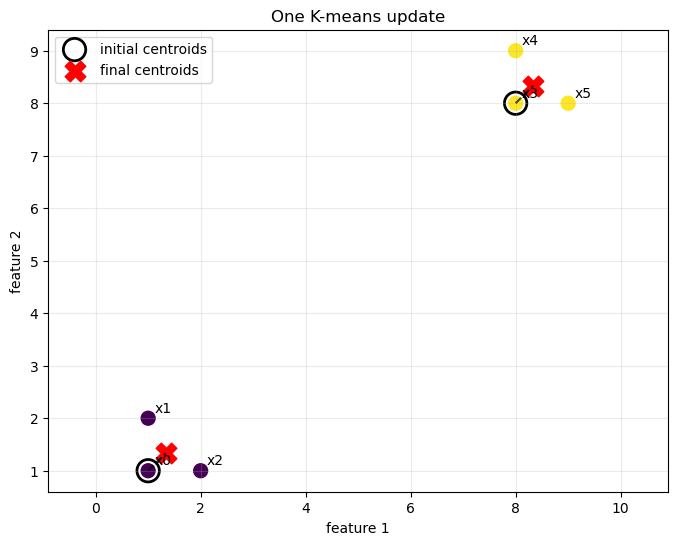

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=sklearn_labels, cmap="viridis", s=100)
plt.scatter(
    initial_centers[:, 0], initial_centers[:, 1],
    facecolors="none", edgecolors="black", s=260, linewidths=2,
    label="initial centroids",
)
plt.scatter(
    model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
    c="red", marker="X", s=220, label="final centroids",
)

for old, new in zip(initial_centers, model.cluster_centers_):
    plt.plot([old[0], new[0]], [old[1], new[1]], "k--", alpha=0.7)

for index, point in enumerate(X):
    plt.annotate(f"x{index}", point + 0.12)

plt.title("One K-means update")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 9. 为什么算法会停止？

K-means 的两个步骤都会让目标函数不增大：

```text
分配步骤 -> 每个样本选择最近质心，不会主动选更远的质心
更新步骤 -> 对固定簇使用均值，使簇内平方和最小
```

因此 SSE 会逐步下降或保持不变，不会无限上升。

当簇分配不再改变，或者质心移动非常小时，算法停止。

但是要注意：

> K-means 通常只能保证到达一个局部最优结果，不能保证一定找到全局最优结果。

不同初始质心可能走向不同结果，这就是后面要学习 `k-means++` 和 `n_init` 的原因。

## 10. 为什么不能只追求更小的 inertia？

如果不断增大 `K`，每个簇包含的样本会越来越少，样本自然更靠近质心，所以 `inertia_` 通常单调下降。

极端情况下：

```text
K = 样本数量
-> 每个样本单独成为一个簇
-> 每个样本就是自己的质心
-> inertia = 0
```

数学目标虽然达到最小，但这种分组通常没有总结和发现结构的价值。

所以选择 `K` 时要在两者之间平衡：

```text
簇内足够紧密
+
簇数量不要复杂到失去解释意义
```

下一课会正式学习肘部法和轮廓系数。

K=1: inertia=149.6667
K=2: inertia=2.6667
K=3: inertia=1.8333
K=4: inertia=1.0000
K=5: inertia=0.5000
K=6: inertia=0.0000


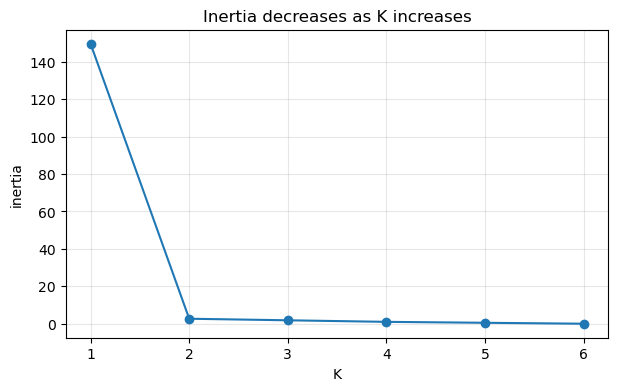

In [9]:
# 预览：同一数据使用不同 K 时，inertia 会怎样变化？
inertias = []
candidate_k = range(1, 7)

for k in candidate_k:
    candidate_model = KMeans(n_clusters=k, random_state=22, n_init=10)
    candidate_model.fit(X)
    inertias.append(candidate_model.inertia_)

for k, inertia in zip(candidate_k, inertias):
    print(f"K={k}: inertia={inertia:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(list(candidate_k), inertias, marker="o")
plt.title("Inertia decreases as K increases")
plt.xlabel("K")
plt.ylabel("inertia")
plt.xticks(list(candidate_k))
plt.grid(alpha=0.3)
plt.show()

## 11. 本课小结

本课需要抓住六点：

1. K-means 用欧氏距离判断样本离哪个质心最近；
2. 比较远近时可以省略平方根，直接比较平方距离；
3. 分配步骤产生每个样本的簇编号；
4. 更新步骤使用簇内均值作为新质心；
5. SSE、WCSS 和 `inertia_` 都在衡量簇内平方距离；
6. `inertia_` 会随 `K` 增大而下降，所以不能单独决定最佳 `K`。

核心计算链：

```text
样本和质心作差
-> 对特征平方并求和
-> argmin 得到簇编号
-> 对每个簇求均值
-> 重新计算 SSE
```

下一课：**如何选择 K——肘部法与轮廓系数**。